## listings basis sorting ratings and number of reviews

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# === Load dataset ===
listings = pd.read_csv("listings.csv", low_memory=False)

# === Select relevant columns ===
cols = [
    'id', 
    'name', 
    'neighbourhood_cleansed', 
    'room_type', 
    'price', 
    'number_of_reviews',
    'review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

df = listings[cols].copy()
df.head()

,id,name,neighbourhood_cleansed,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,2992450,Luxury 2 bedroom apartment,THIRD WARD,Entire home/apt,$70.00,9,3.56,3.44,3.56,4.22,4.56,3.22,3.67
1,3820211,Restored Precinct in Center Sq. w/Parking,SIXTH WARD,Entire home/apt,$100.00,308,4.75,4.89,4.87,4.85,4.81,4.83,4.78
2,5651579,Large studio apt by Capital Center & ESP@,SECOND WARD,Entire home/apt,$75.00,371,4.51,4.62,4.45,4.81,4.88,4.76,4.64
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,SIXTH WARD,Entire home/apt,$95.00,331,4.73,4.83,4.71,4.82,4.70,4.80,4.72
4,9005989,"Studio in The heart of Center SQ, in Albany NY",SIXTH WARD,Entire home/apt,$86.00,620,4.80,4.86,4.83,4.95,4.93,4.87,4.77


In [4]:
# === Clean price column ===
df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# === Drop listings without overall rating ===
df = df.dropna(subset=['review_scores_rating'])

# === Convert overall rating from 0–100 → 0–5 stars ===
df['rating_stars'] = df['review_scores_rating'] / 20


In [5]:
df.head()

,id,name,neighbourhood_cleansed,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,rating_stars
0,2992450,Luxury 2 bedroom apartment,THIRD WARD,Entire home/apt,70.0,9,3.56,3.44,3.56,4.22,4.56,3.22,3.67,0.1780
1,3820211,Restored Precinct in Center Sq. w/Parking,SIXTH WARD,Entire home/apt,100.0,308,4.75,4.89,4.87,4.85,4.81,4.83,4.78,0.2375
2,5651579,Large studio apt by Capital Center & ESP@,SECOND WARD,Entire home/apt,75.0,371,4.51,4.62,4.45,4.81,4.88,4.76,4.64,0.2255
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,SIXTH WARD,Entire home/apt,95.0,331,4.73,4.83,4.71,4.82,4.70,4.80,4.72,0.2365
4,9005989,"Studio in The heart of Center SQ, in Albany NY",SIXTH WARD,Entire home/apt,86.0,620,4.80,4.86,4.83,4.95,4.93,4.87,4.77,0.2400


In [6]:
#=== Top 10 overall properties ===
top_overall = df.sort_values(
    by=['review_scores_rating', 'number_of_reviews'],
    ascending=[False, False]
).head(10)

print("\n=== Top 10 Properties by Overall Rating ===\n")
print(top_overall[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', 'review_scores_rating', 'rating_stars', 'number_of_reviews']])



=== Top 10 Properties by Overall Rating ===

                      id                                              name  \
259  1004978540001566331    Elegant Albany Retreat | Mins to D/T & UAlbany   
240   938431811499141903              The little room with TV and twin bed   
175   764508866835218670       Rest+Restore Room • Short & Extended Stay •   
34              27670660                             The Rock & Roll Suite   
265  1013659440189111738  Abba House Historic Retreat - 2nd Floor Full Bed   
326  1183457852972127594                   Upscale Listing-Heart of Albany   
191   803682039097862541  Modern and Cozy Pine Hills Home from Early 1900s   
243   942750363293463100              The spacious room w/ tv dresser/desk   
218   904392960639597224                   /Luxury Modern Western Hideout\   
208   850653820133738660  Plum room, private queen near hospitals, UAlbany   

    neighbourhood_cleansed        room_type  price  review_scores_rating  \
259            EIGH

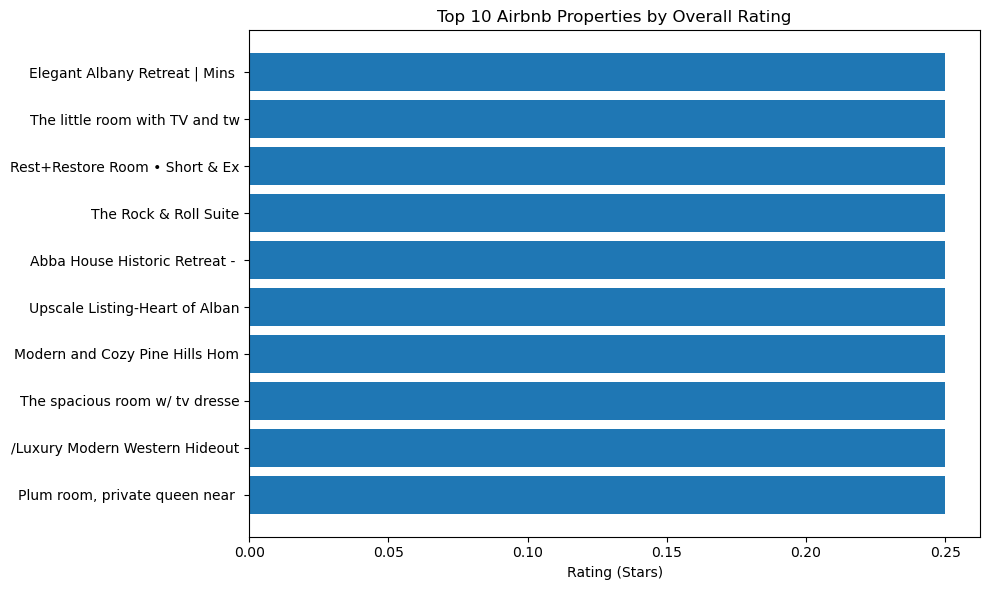

In [7]:
# === Plot Top 10 Overall ===
plt.figure(figsize=(10,6))
plt.barh(top_overall['name'].str[:30], top_overall['rating_stars'])
plt.gca().invert_yaxis()
plt.xlabel("Rating (Stars)")
plt.title("Top 10 Airbnb Properties by Overall Rating")
plt.tight_layout()
plt.show()


=== Top 5 Properties by Accuracy ===

                      id                                               name  \
160   724566770267420045    Cozy Greenwood Flat (1 BDR Apartment in Albany)   
164   739722503092755616                                Adirondack Suite #1   
367  1273958657689116365                               3 Bedroom Cozy Ranch   
166   744430701454304507  1 Bedroom on Lincoln Park, near Lark and Downtown   
299  1120212616553191970  Garden Apt Suite in Historic 1858 Row House + W/D   

    neighbourhood_cleansed        room_type  price  review_scores_accuracy  \
160             SIXTH WARD  Entire home/apt  101.0                     5.0   
164             NINTH WARD     Private room   60.0                     5.0   
367         FIFTEENTH WARD  Entire home/apt  164.0                     5.0   
166           SEVENTH WARD  Entire home/apt   77.0                     5.0   
299             SIXTH WARD  Entire home/apt   87.0                     5.0   

     number_of_re

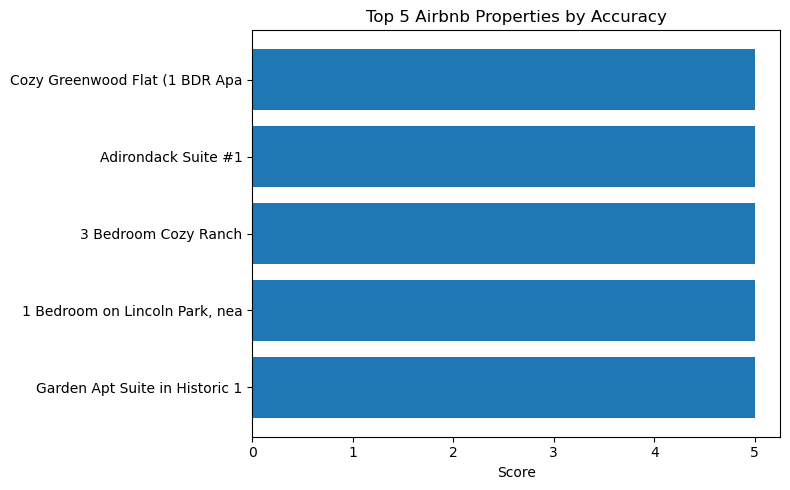


=== Top 5 Properties by Cleanliness ===

                      id                                               name  \
148   668608096674070882  The Historic J. Buel Farmhouse-  Rose Feather ...   
129   593272120497643087      The Historic J. Buel Farmhouse - Luxury Suite   
139   634108143238179968   Perfect for Families and Traveling Professionals   
15              18341426     /Sauna Ranch 1961\ SUNY Eagle Hill 4Beds 1Bath   
291  1097995825442731795                           New Center square studio   

    neighbourhood_cleansed        room_type  price  review_scores_cleanliness  \
148        FOURTEENTH WARD     Private room   60.0                        5.0   
129        THIRTEENTH WARD     Private room   96.0                        5.0   
139             SIXTH WARD  Entire home/apt    NaN                        5.0   
15          FIFTEENTH WARD  Entire home/apt  376.0                        5.0   
291             SIXTH WARD  Entire home/apt   88.0                        5.0 

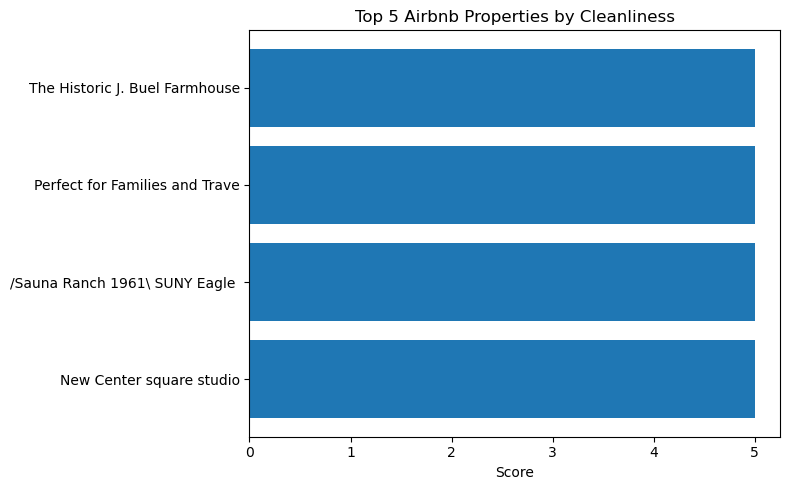


=== Top 5 Properties by Checkin ===

                      id                                               name  \
200   831122937768017113                Boho-Chic Cape Conveniently Located   
160   724566770267420045    Cozy Greenwood Flat (1 BDR Apartment in Albany)   
259  1004978540001566331     Elegant Albany Retreat | Mins to D/T & UAlbany   
291  1097995825442731795                           New Center square studio   
87              48470454  / New Giant Victorian \ 7beds 6 baths + 2x 85"...   

    neighbourhood_cleansed        room_type  price  review_scores_checkin  \
200         FIFTEENTH WARD  Entire home/apt  246.0                    5.0   
160             SIXTH WARD  Entire home/apt  101.0                    5.0   
259            EIGHTH WARD  Entire home/apt  163.0                    5.0   
291             SIXTH WARD  Entire home/apt   88.0                    5.0   
87         THIRTEENTH WARD  Entire home/apt  511.0                    5.0   

     number_of_reviews  

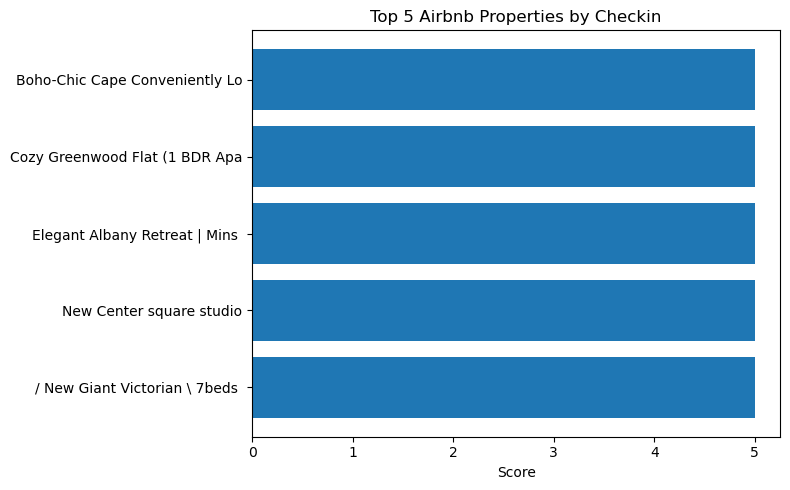


=== Top 5 Properties by Communication ===

           id                                               name  \
68   44265426      Parkside Queen 1 Bedroom (1800's) Brownstone!   
122  54128829  Modern & Cozy Cntr Square Townhouse Gem from 1854   
123  54150131  Charming 170-Year-Old Home in the Heart of Albany   
110  52863776  Washington Parkside 1 Bedroom In 1800s Brownst...   
90   50171851          Beautiful Center Square Garden-Level Unit   

    neighbourhood_cleansed        room_type  price  \
68              SIXTH WARD  Entire home/apt  103.0   
122             SIXTH WARD  Entire home/apt  144.0   
123             SIXTH WARD  Entire home/apt  164.0   
110             SIXTH WARD  Entire home/apt  105.0   
90              SIXTH WARD  Entire home/apt    NaN   

     review_scores_communication  number_of_reviews  
68                           5.0                302  
122                          5.0                243  
123                          5.0                224  
110   

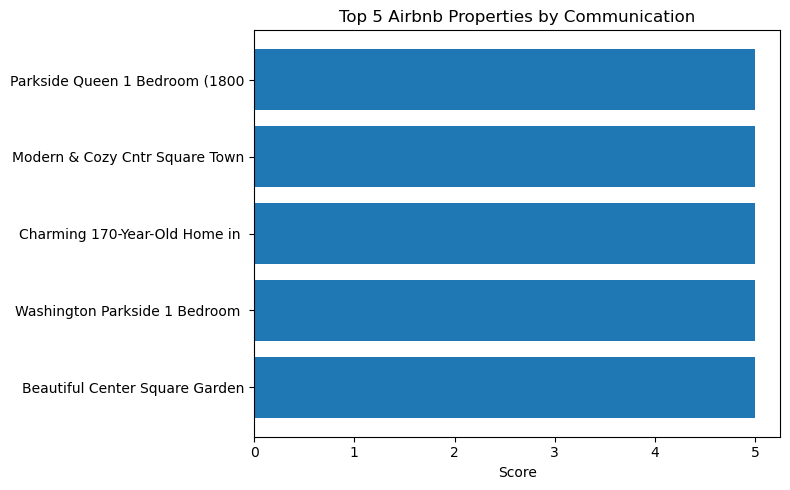


=== Top 5 Properties by Location ===

                      id                                          name  \
243   942750363293463100          The spacious room w/ tv dresser/desk   
327  1183460523409924571               Albany Business Class Apartment   
35              27692601  Albany Cozy home with fireplaces and Sunroom   
172   757342235277207834               Elegant Studio in Center Square   
408  1366933239765507591                       Vacation Home in Albany   

    neighbourhood_cleansed        room_type  price  review_scores_location  \
243          ELEVENTH WARD     Private room   54.0                     5.0   
327             SIXTH WARD  Entire home/apt   67.0                     5.0   
35             EIGHTH WARD  Entire home/apt  302.0                     5.0   
172             SIXTH WARD  Entire home/apt   65.0                     5.0   
408            EIGHTH WARD  Entire home/apt  258.0                     5.0   

     number_of_reviews  
243                 19

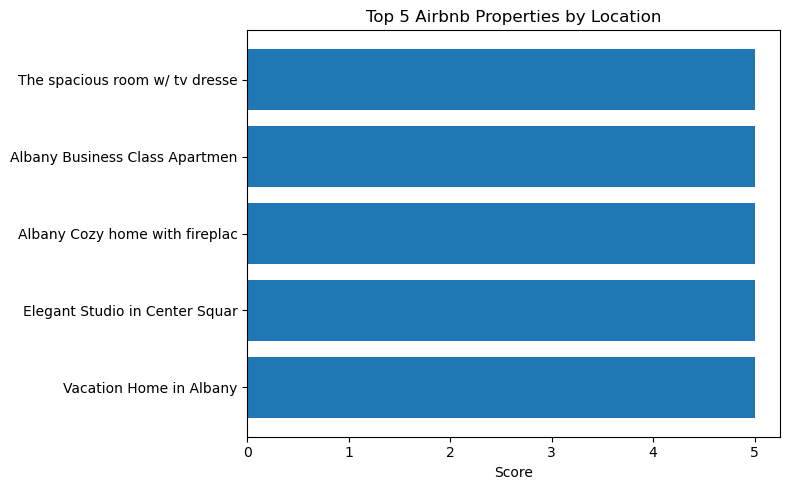


=== Top 5 Properties by Value ===

                      id                                              name  \
259  1004978540001566331    Elegant Albany Retreat | Mins to D/T & UAlbany   
175   764508866835218670       Rest+Restore Room • Short & Extended Stay •   
252   980034348801186320                             Chic Madison Parkview   
191   803682039097862541  Modern and Cozy Pine Hills Home from Early 1900s   
243   942750363293463100              The spacious room w/ tv dresser/desk   

    neighbourhood_cleansed        room_type  price  review_scores_value  \
259            EIGHTH WARD  Entire home/apt  163.0                  5.0   
175             TENTH WARD     Private room   77.0                  5.0   
252             SIXTH WARD  Entire home/apt   91.0                  5.0   
191        THIRTEENTH WARD  Entire home/apt  146.0                  5.0   
243          ELEVENTH WARD     Private room   54.0                  5.0   

     number_of_reviews  
259                

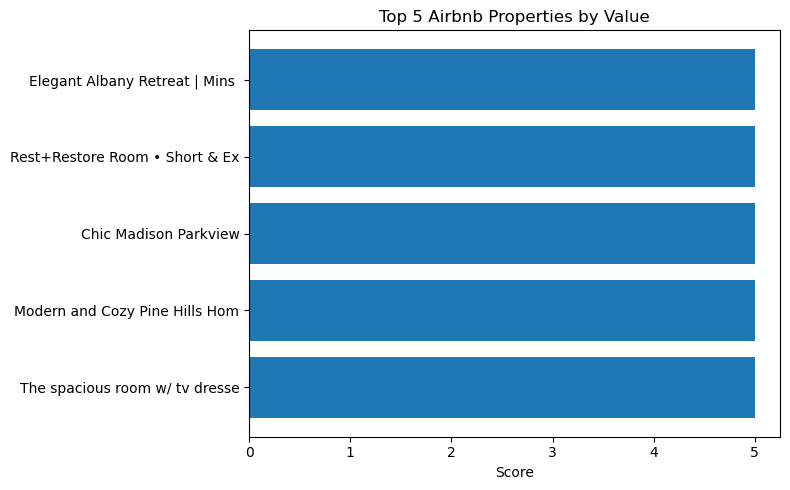

In [8]:
# === Sub-rating categories to analyze ===
sub_ratings = [
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

# === Plot Top 5 properties per sub-rating ===
for col in sub_ratings:
    if col in df.columns:
        top_sub = df.dropna(subset=[col]).sort_values(
            by=[col, 'number_of_reviews'],
            ascending=[False, False]
        ).head(5)

        print(f"\n=== Top 5 Properties by {col.replace('review_scores_', '').capitalize()} ===\n")
        print(top_sub[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', col, 'number_of_reviews']])

        plt.figure(figsize=(8,5))
        plt.barh(top_sub['name'].str[:30], top_sub[col])
        plt.gca().invert_yaxis()
        plt.xlabel("Score")
        plt.title(f"Top 5 Airbnb Properties by {col.replace('review_scores_', '').capitalize()}")
        plt.tight_layout()
        plt.show()


## value-for-money index analysis

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Load dataset ===
listings = pd.read_csv("listings.csv", low_memory=False)

# === Select relevant columns ===
cols = [
    'id', 'name', 'neighbourhood_cleansed', 'room_type',
    'price', 'number_of_reviews', 'review_scores_rating'
]
df = listings[cols].copy()

In [10]:
# === Clean price column ===
df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# === Drop rows without ratings or prices ===
df = df.dropna(subset=['review_scores_rating', 'price'])
df = df[df['price'] > 0]  # avoid division by zero

# === Convert Airbnb rating (0-100) → 0-5 stars ===
df['rating_stars'] = df['review_scores_rating'] / 20


In [15]:
df.head()

,id,name,neighbourhood_cleansed,room_type,price,number_of_reviews,review_scores_rating,rating_stars,value_index_log,value_index_norm
0,2992450,Luxury 2 bedroom apartment,THIRD WARD,Entire home/apt,70.0,9,3.56,0.1780,0.041758,0.244114
1,3820211,Restored Precinct in Center Sq. w/Parking,SIXTH WARD,Entire home/apt,100.0,308,4.75,0.2375,0.051461,0.228000
2,5651579,Large studio apt by Capital Center & ESP@,SECOND WARD,Entire home/apt,75.0,371,4.51,0.2255,0.052070,0.288640
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,SIXTH WARD,Entire home/apt,95.0,331,4.73,0.2365,0.051815,0.238989
4,9005989,"Studio in The heart of Center SQ, in Albany NY",SIXTH WARD,Entire home/apt,86.0,620,4.80,0.2400,0.053740,0.267907


In [11]:
# --- Method 1: Log-based Value Index ---
df['value_index_log'] = df['rating_stars'] / np.log1p(df['price'])

# --- Method 2: Normalized Price Value Index ---
median_price = df['price'].median()
df['value_index_norm'] = df['rating_stars'] / (df['price'] / median_price)


In [12]:
#=== Find Top 10 Best Deals (Log-based) ===
top_log = df.sort_values(by='value_index_log', ascending=False).head(10)
print("\n=== Top 10 Best Value Listings (Log-based Index) ===\n")
print(top_log[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', 'rating_stars', 'value_index_log']])



=== Top 10 Best Value Listings (Log-based Index) ===

                      id                                            name  \
240   938431811499141903            The little room with TV and twin bed   
27              21769439      Cozy upstairs room with (1) walk-in closet   
26              21769213  Cozy downstairs bedroom in quiet neighborhood!   
22              21052414           Cozy bedroom with (2) walk-in closets   
86              48172884                            The Down Under Suite   
384  1296756366433115082                              Room In Albany, NY   
213   887167811237271928                                  The Comfort II   
102             51954621          Queen bed w/garden hammocks & home gym   
383  1296651761769034648                                  Room in Albany   
428  1393634936904017469                  New Bedroom! Includes Parking!   

    neighbourhood_cleansed     room_type  price  rating_stars  value_index_log  
240        THIRTEENTH WARD 

In [13]:
# === Find Top 10 Best Deals (Normalized-based) ===
top_norm = df.sort_values(by='value_index_norm', ascending=False).head(10)
print("\n=== Top 10 Best Value Listings (Normalized Price Index) ===\n")
print(top_norm[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', 'rating_stars', 'value_index_norm']])



=== Top 10 Best Value Listings (Normalized Price Index) ===

                      id                                               name  \
27              21769439         Cozy upstairs room with (1) walk-in closet   
22              21052414              Cozy bedroom with (2) walk-in closets   
213   887167811237271928                                     The Comfort II   
26              21769213     Cozy downstairs bedroom in quiet neighborhood!   
240   938431811499141903               The little room with TV and twin bed   
383  1296651761769034648                                     Room in Albany   
86              48172884                               The Down Under Suite   
384  1296756366433115082                                 Room In Albany, NY   
335  1192795085655166314  Privateroom with shared bathroom for Nurses&grads   
102             51954621             Queen bed w/garden hammocks & home gym   

    neighbourhood_cleansed     room_type  price  rating_stars  \
27 

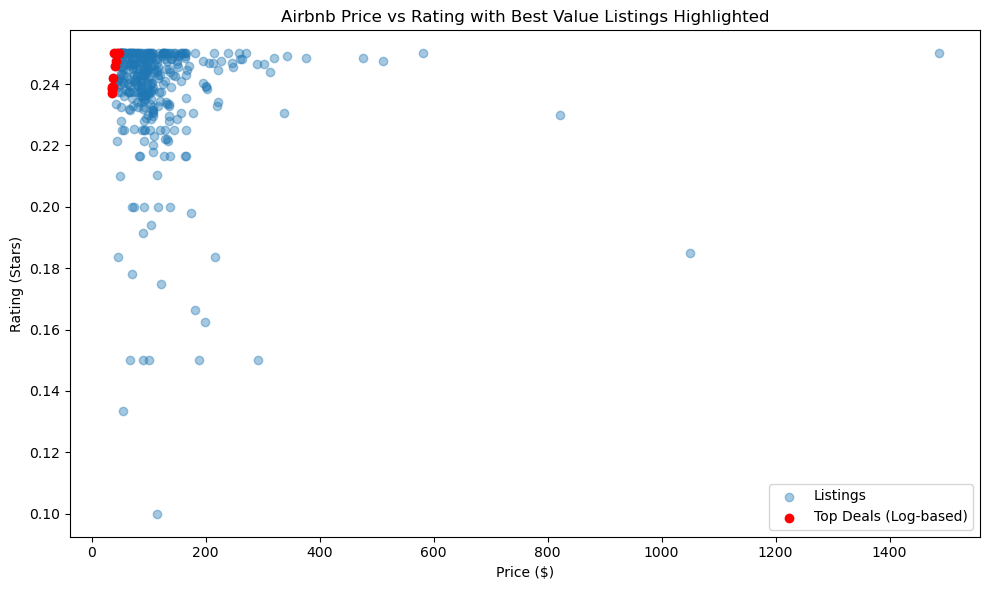

In [14]:
# === Scatterplot Comparison ===
plt.figure(figsize=(10,6))
plt.scatter(df['price'], df['rating_stars'], alpha=0.4, label='Listings')
plt.scatter(top_log['price'], top_log['rating_stars'], color='red', label='Top Deals (Log-based)')
plt.xlabel("Price ($)")
plt.ylabel("Rating (Stars)")
plt.title("Airbnb Price vs Rating with Best Value Listings Highlighted")
plt.legend()
plt.tight_layout()
plt.show()